# 1.0 - Exploration des Données (EDA)

Ce notebook effectue une analyse exploratoire sur les données brutes (ex: IMDB).

**Objectifs :**
1. Charger les données.
2. Analyser la distribution des classes (sentiments).
3. Analyser la longueur des textes.
4. Identifier les mots les plus fréquents (avant nettoyage).
5. Visualiser des exemples de textes bruts (pour identifier le bruit : HTML, URLs, etc.)

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
import sys
from pathlib import Path

%matplotlib inline
sns.set_theme(style="whitegrid")

project_root = str(Path.cwd().parent)
if project_root not in sys.path:
    sys.path.append(project_root)

from src.preprocessing.text_cleaner import clean_text

## 1. Chargement des Données

In [2]:
RAW_DATA_PATH = "../data/raw/IMDB Dataset.csv"

try:
    df = pd.read_csv(RAW_DATA_PATH)
    print(f"Données chargées : {df.shape}")
    display(df.head())
except FileNotFoundError:
    print(f"Erreur: Fichier non trouvé à {RAW_DATA_PATH}")
    print("Veuillez télécharger le dataset IMDB et le placer dans data/raw/")

Données chargées : (50000, 2)


,review,sentiment
0,One of the other reviewers has mentioned that ...,positive
1,A wonderful little production. <br /><br />The...,positive
2,I thought this was a wonderful way to spend ti...,positive
3,Basically there's a family where a little boy ...,negative
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive


## 2. Distribution des Classes

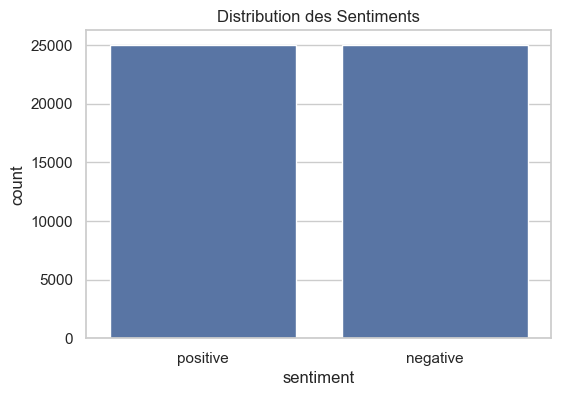

sentiment
positive    0.5
negative    0.5
Name: proportion, dtype: float64


In [3]:
plt.figure(figsize=(6, 4))
sns.countplot(data=df, x='sentiment')
plt.title('Distribution des Sentiments')
plt.show()

print(df['sentiment'].value_counts(normalize=True))

## 3. Analyse de la Longueur des Textes (en mots)

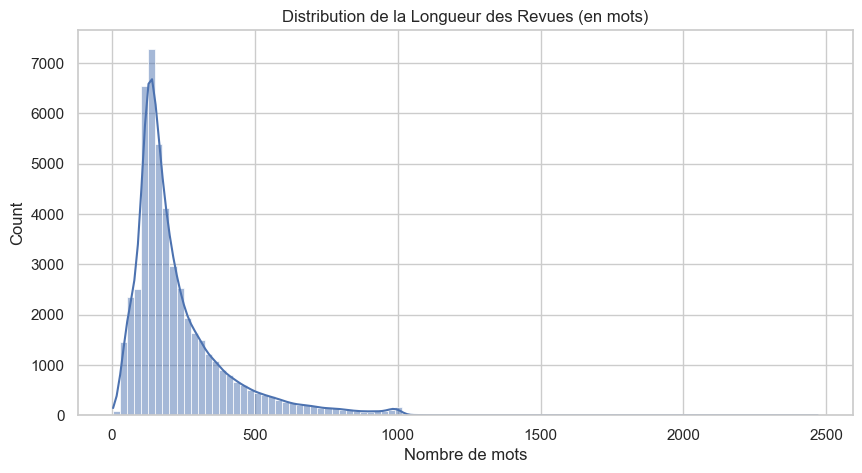

count    50000.000000
mean       231.156940
std        171.343997
min          4.000000
25%        126.000000
50%        173.000000
75%        280.000000
max       2470.000000
Name: word_count, dtype: float64

In [4]:
df['word_count'] = df['review'].astype(str).apply(lambda x: len(x.split()))

plt.figure(figsize=(10, 5))
sns.histplot(df['word_count'], bins=100, kde=True)
plt.title('Distribution de la Longueur des Revues (en mots)')
plt.xlabel('Nombre de mots')
plt.show()

display(df['word_count'].describe())

## 4. Mots les plus fréquents (Avant Nettoyage)

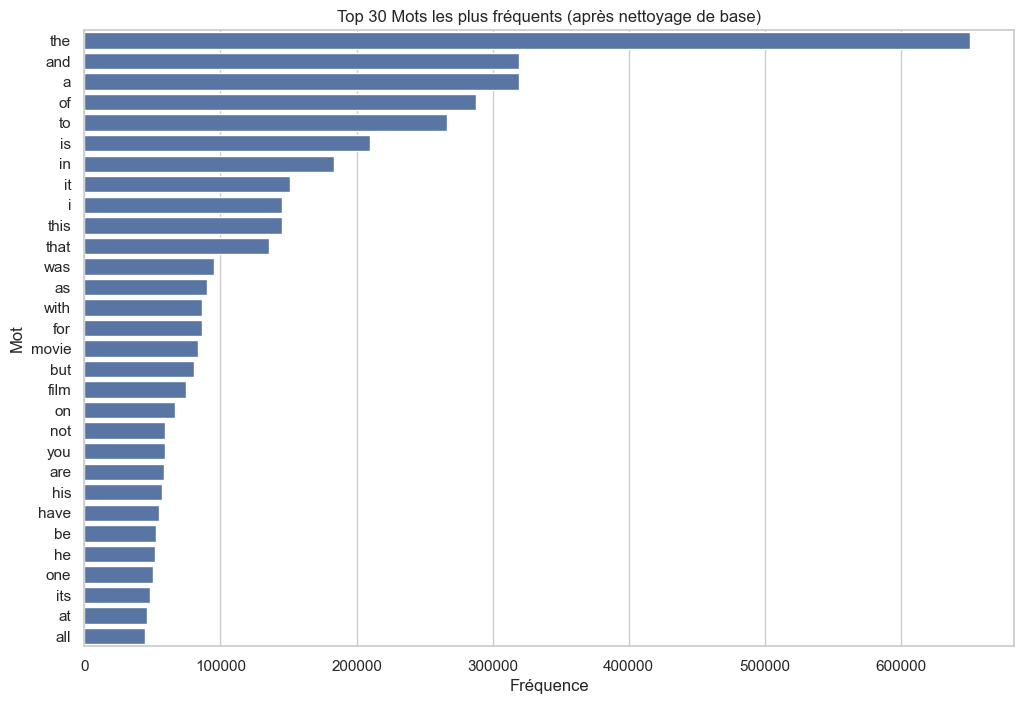

In [5]:
# Nous appliquons un nettoyage *léger* (juste clean_text, pas la normalisation)
# pour avoir une idée des mots pertinents vs bruit.
df['temp_clean'] = df['review'].apply(clean_text)

word_counts = Counter(" ".join(df['temp_clean']).split()).most_common(30)
word_freq_df = pd.DataFrame(word_counts, columns=['Mot', 'Fréquence'])

plt.figure(figsize=(12, 8))
sns.barplot(data=word_freq_df, x='Fréquence', y='Mot')
plt.title('Top 30 Mots les plus fréquents (après nettoyage de base)')
plt.show()

# On peut voir que les stopwords (the, a, is, etc.) dominent.

## 5. Exemples de Bruit (HTML, etc.)

In [6]:
html_examples = df[df['review'].str.contains("<br />", na=False)]

print(f"Exemples contenant des balises HTML : {len(html_examples)}")
if not html_examples.empty:
    print("\n--- EXEMPLE DE TEXTE BRUT ---")
    print(html_examples.iloc[0]['review'])
    print("\n--- EXEMPLE NETTOYÉ (avec clean_text) ---")
    print(clean_text(html_examples.iloc[0]['review']))

Exemples contenant des balises HTML : 29200

--- EXEMPLE DE TEXTE BRUT ---
One of the other reviewers has mentioned that after watching just 1 Oz episode you'll be hooked. They are right, as this is exactly what happened with me.<br /><br />The first thing that struck me about Oz was its brutality and unflinching scenes of violence, which set in right from the word GO. Trust me, this is not a show for the faint hearted or timid. This show pulls no punches with regards to drugs, sex or violence. Its is hardcore, in the classic use of the word.<br /><br />It is called OZ as that is the nickname given to the Oswald Maximum Security State Penitentary. It focuses mainly on Emerald City, an experimental section of the prison where all the cells have glass fronts and face inwards, so privacy is not high on the agenda. Em City is home to many..Aryans, Muslims, gangstas, Latinos, Christians, Italians, Irish and more....so scuffles, death stares, dodgy dealings and shady agreements are never far